In [1]:
import pandas as pd

In [2]:
train_df = pd.read_csv('../results/outputs/Selected/train_top10_features.csv')
test_df = pd.read_csv('../results/outputs/Selected/test_top10_features.csv')

In [3]:
train_df_pca = pd.read_csv('../results/outputs/PCA/pca_train.csv')
test_df_pca = pd.read_csv('../results/outputs/PCA/pca_test.csv')

In [4]:
feature_cols = [c for c in train_df.columns if c != "target"]

x_train = train_df[feature_cols]
y_train = train_df["target"]

x_test = test_df[feature_cols]
y_test = test_df["target"]

In [5]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

In [6]:
nb = GaussianNB()
nb.fit(x_train, y_train)

nb_preds = nb.predict(x_test)
nb_accuracy = accuracy_score(y_test, nb_preds)

nb_preds_train = nb.predict(x_train)
nb_accuracy_train = accuracy_score(y_train, nb_preds_train)

print("Naive Bayes Accuracy (Test):", nb_accuracy)
print("Naive Bayes Accuracy (Train):", nb_accuracy_train)
print(classification_report(y_test, nb_preds))

Naive Bayes Accuracy (Test): 0.8954545454545455
Naive Bayes Accuracy (Train): 0.8875
              precision    recall  f1-score   support

           0       0.95      0.82      0.88        74
           1       1.00      0.89      0.94        72
           2       0.78      0.97      0.87        74

    accuracy                           0.90       220
   macro avg       0.91      0.90      0.90       220
weighted avg       0.91      0.90      0.90       220



In [ ]:
#traying PCA dataset

In [8]:
feature_cols_pca = [c for c in train_df_pca.columns if c != "target"]

x_train_pca = train_df_pca[feature_cols_pca]
y_train_pca = train_df_pca["target"]

x_test_pca = test_df_pca[feature_cols_pca]
y_test_pca = test_df_pca["target"]

In [9]:
nb = GaussianNB()
nb.fit(x_train_pca, y_train_pca)

nb_preds_pca = nb.predict(x_test_pca)
nb_accuracy_pca = accuracy_score(y_test_pca, nb_preds_pca)

nb_preds_train_pca = nb.predict(x_train_pca)
nb_accuracy_train_pca = accuracy_score(y_train_pca, nb_preds_train_pca)

print("Naive Bayes Accuracy (Test):", nb_accuracy_pca)
print("Naive Bayes Accuracy (Train):", nb_accuracy_train_pca)
print(classification_report(y_test_pca, nb_preds_pca))

Naive Bayes Accuracy (Test): 0.8590909090909091
Naive Bayes Accuracy (Train): 0.8784090909090909
              precision    recall  f1-score   support

           0       0.98      0.78      0.87        74
           1       0.79      0.94      0.86        72
           2       0.84      0.85      0.85        74

    accuracy                           0.86       220
   macro avg       0.87      0.86      0.86       220
weighted avg       0.87      0.86      0.86       220



In [ ]:
#PCA dataset accuracy is lower compared to  feature seleceted dataset
#Moving on to hyper parameter tuning with feature selected dataset

In [7]:
from sklearn.model_selection import GridSearchCV
import numpy as np

In [11]:
nb_param_grid = {'var_smoothing': np.logspace(-11, -7, 20)}

grid_nb = GridSearchCV(GaussianNB(), nb_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_nb.fit(x_train, y_train)

print("Best var_smoothing:", grid_nb.best_params_)
print("Best CV accuracy:", grid_nb.best_score_)

best_nb = grid_nb.best_estimator_
tuned_nb_preds = best_nb.predict(x_test)
print("Tuned Naive Bayes Test Accuracy:", accuracy_score(y_test, tuned_nb_preds))
print(classification_report(y_test, tuned_nb_preds))

Best var_smoothing: {'var_smoothing': np.float64(1.2742749857031322e-09)}
Best CV accuracy: 0.8886363636363637
Tuned Naive Bayes Test Accuracy: 0.8954545454545455
              precision    recall  f1-score   support

           0       0.95      0.82      0.88        74
           1       1.00      0.89      0.94        72
           2       0.78      0.97      0.87        74

    accuracy                           0.90       220
   macro avg       0.91      0.90      0.90       220
weighted avg       0.91      0.90      0.90       220



In [ ]:
#Confusion matrix

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

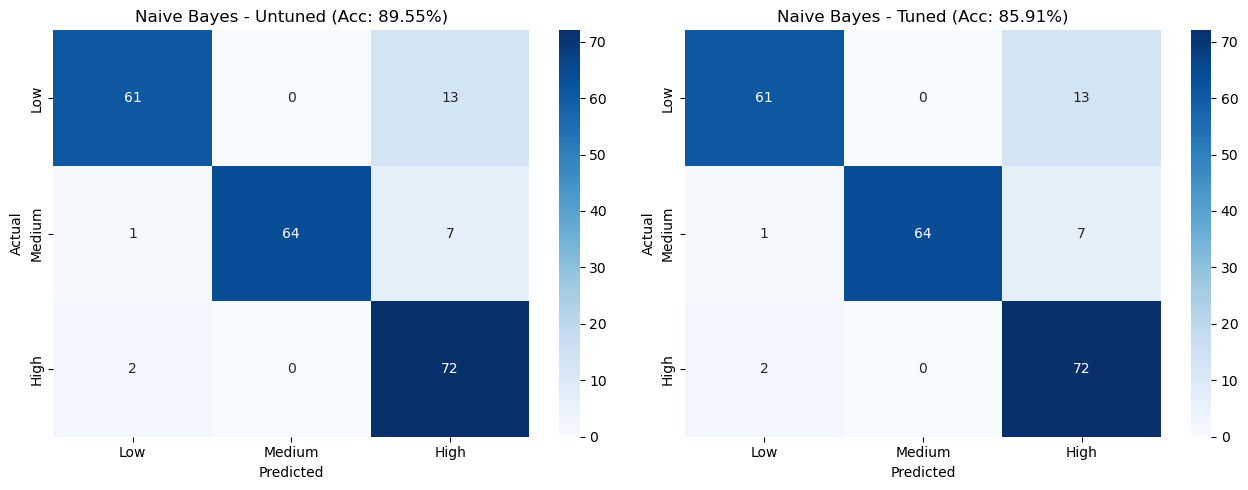

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_tn = confusion_matrix(y_test, tuned_nb_preds)

cm_unt = confusion_matrix(y_test, nb_preds)
sns.heatmap(cm_unt, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
axes[0].set_title(f"Naive Bayes - Untuned (Acc: {nb_accuracy:.2%})")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_tn, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
axes[1].set_title(f"Naive Bayes - Tuned (Acc: {nb_accuracy_pca:.2%})")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("../results/eda_visualizations/nb_confusion_comparison_tuned_vs_untuned.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#Both are identical meaning model is on deafult have the best parameters for this dataset

In [14]:
import joblib
joblib.dump(nb, "../results/model_trained_files/naive_bayes.pkl")

['../results/model_trained_files/naive_bayes.pkl']